# Customer Churn Prediction — Model Evaluation (Notebook 4 of 4)

**Goal of this notebook:** Properly evaluate the trained model, explain its predictions, and export results for the Power BI dashboard.
**Why:** With ~26% churn, accuracy alone is misleading — a model that predicts "no churn" for everyone would still look 74% accurate while being useless. Precision, recall, ROC-AUC, and SHAP tell the real story: does the model actually catch churners, and why does it flag them?
**Input:** `../outputs/churn_pipeline.pkl` and train/test splits (saved in notebook 3)
**Output:** `../outputs/churn_predictions.csv` for Power BI

In [2]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

pipeline = joblib.load("../outputs/churn_pipeline.pkl")

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

X_test.shape, y_test.shape

((1409, 21), (1409,))

### Generate predictions
Getting both the predicted class (churn/no churn) and the predicted probability — the probability is what makes the risk score useful in the dashboard, not just a yes/no flag.

In [3]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

y_pred[:10], y_proba[:10]

(array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1]),
 array([0.01866855, 0.719805  , 0.08149229, 0.3641933 , 0.03585768,
        0.70848907, 0.4743442 , 0.15504801, 0.00269876, 0.55510709]))

### Classification report
Precision tells me: of everyone flagged as a churn risk, how many actually churned. Recall tells me: of everyone who actually churned, how many did the model catch. For a retention use case, recall on the churn class matters most — missing a churner is worse than a false alarm.

In [4]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.84      1035
       Churn       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



### ROC-AUC score
This measures how well the model separates churners from non-churners across all thresholds — a better overall measure than accuracy for imbalanced data.

In [5]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8376


### Confusion matrix
Visualizing exactly how many churners were correctly caught, missed, or false-alarmed.

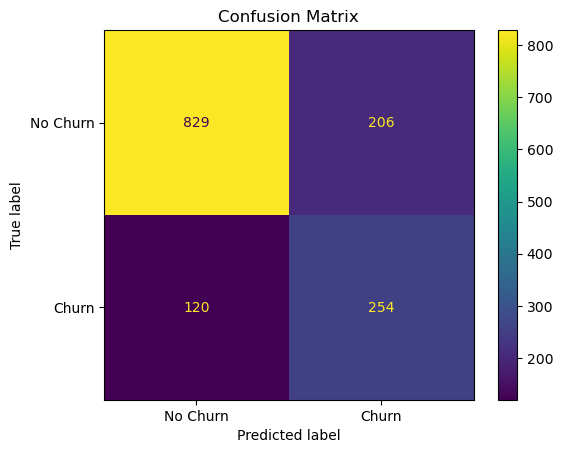

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.show()

### ROC curve
Plotting the tradeoff between catching churners (true positive rate) and false alarms (false positive rate) across thresholds.

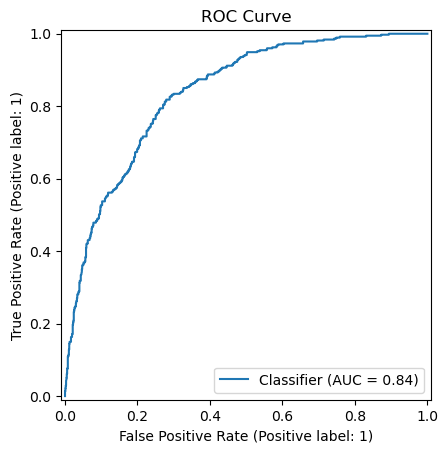

In [7]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve')
plt.show()

### SHAP feature importance
Accuracy alone doesn't help the business — the retention team needs to know *why* someone is flagged as high-risk. SHAP shows which features push a prediction toward "churn" and by how much, for the model as a whole and for individual customers.

In [8]:
!pip install shap

In [9]:
import shap

X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

<class 'numpy.ndarray'>
(1409, 51, 2)


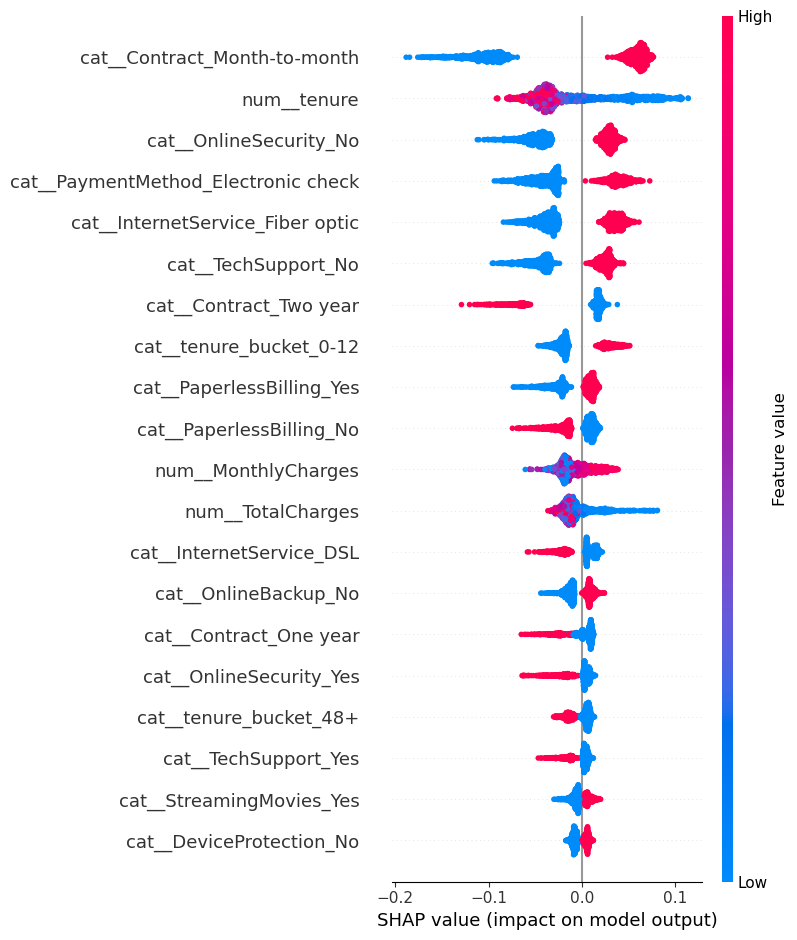

In [11]:
# shap 0.52.0 returns shape (samples, features, classes) for classifiers
# older versions return a list [class0_values, class1_values]

if isinstance(shap_values, list):
    values_for_churn = shap_values[1]
elif shap_values.ndim == 3:
    values_for_churn = shap_values[:, :, 1]
else:
    values_for_churn = shap_values

shap.summary_plot(values_for_churn, X_test_transformed, feature_names=feature_names)

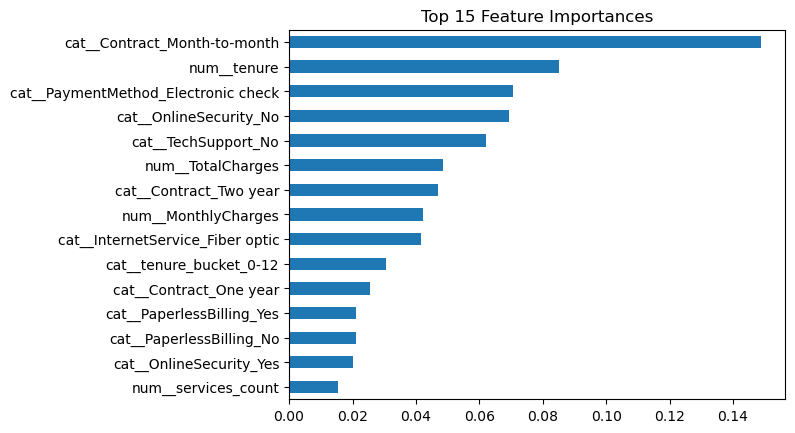

In [12]:
import pandas as pd

importances = pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

In [13]:
avg_monthly_charge = X_test['MonthlyCharges'].mean()
flagged_at_risk = (y_pred == 1).sum()
potential_monthly_revenue_at_risk = flagged_at_risk * avg_monthly_charge

print(f"Customers flagged as at-risk: {flagged_at_risk}")
print(f"Average monthly charge: ${avg_monthly_charge:.2f}")
print(f"Potential monthly revenue at risk: ${potential_monthly_revenue_at_risk:,.2f}")

Customers flagged as at-risk: 460
Average monthly charge: $64.09
Potential monthly revenue at risk: $29,480.87


In [14]:
results = X_test.copy()
results['actual_churn'] = y_test.values
results['predicted_churn'] = y_pred
results['churn_probability'] = y_proba

results.to_csv("../outputs/churn_predictions.csv", index=False)
results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_bucket,services_count,actual_churn,predicted_churn,churn_probability
0,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Two year,Yes,Credit card (automatic),114.05,8468.20,48+,6,0,0,0.018669
1,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0-12,3,0,1,0.719805
2,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,...,One year,Yes,Credit card (automatic),78.35,3211.20,25-48,4,0,0,0.081492
3,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,78.20,1468.75,13-24,2,0,0,0.364193
4,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Two year,Yes,Credit card (automatic),82.65,5919.35,48+,5,0,0,0.035858


## Summary
- ROC-AUC: fill in from output above
- Recall on churn class: fill in from classification report
- Top SHAP/feature-importance drivers: fill in from plot
- Estimated monthly revenue at risk: fill in from output above
- Exported `churn_predictions.csv` for Power BI

**Next:** Build Power BI dashboard from `churn_predictions.csv`.

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=['Actual: No Churn', 'Actual: Churn'],
                          columns=['Predicted: No Churn', 'Predicted: Churn'])
cm_df.to_csv("../outputs/confusion_matrix.csv")

importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15)
feat_imp_df.to_csv("../outputs/feature_importance.csv", index=False)

In [16]:
cm_df.to_csv("../outputs/confusion_matrix.csv")
feat_imp_df.to_csv("../outputs/feature_importance.csv", index=False)